# Results

Everything here is read from `results/`, which `run.py` writes. No network, no price cache — the
files this notebook needs are in the repository.

The strategy does not beat the S&P 500. What this notebook is for is the other number: **how much
the first version of the backtest was flattering itself**, measured rather than asserted.

In [1]:
# Load the results run.py wrote. Nothing here touches the network.
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / "qm_strategy.py").exists())
RES = ROOT / "results"

R = json.loads((RES / "backtest_results.json").read_text())
P = R["parameters"]

def curve(name):
    df = pd.read_csv(RES / f"equity_curve_{name}.csv", parse_dates=["date"]).set_index("date")
    return df["value"]

EQ = {k: curve(k) for k in ("honest", "honest_trade_changes_only", "lookahead_fundamentals")}
SPY = pd.read_csv(RES / "spy_curve.csv", parse_dates=["date"]).set_index("date")["spy"]

# house style: static PNGs, so identity is carried by the legend and by direct labels, never by colour alone
C_HONEST, C_LOOK = "#2a78d6", "#eb6834"      # validated categorical slots 1 and 2
C_POS, C_NEG = "#2a78d6", "#e34948"          # diverging pair, blue <-> red
C_BENCH, INK, INK2 = "#6e6d68", "#0b0b0b", "#52514e"
SURFACE = "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.edgecolor": "#c9c8c3", "axes.linewidth": 1.0, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.dpi": 110,
})

print(f"backtest generated {R['generated']} · {P['BACKTEST_START']} to {EQ['honest'].index[-1].date()}"
      f" · {R['backtests']['honest']['rebalances']} rebalances")
print(f"top {P['TOP_N']}, hysteresis {P['HYSTERESIS']}, {P['LOOKBACK_DAYS']}d lookback skipping"
      f" {P['SKIP_DAYS']}d, {P['TX_COST_BPS']} bps a side")

backtest generated 2026-09-09 16:00 · 2007-01-01 to 2026-09-09 · 237 rebalances
top 20, hysteresis 30, 252d lookback skipping 21d, 10 bps a side


## The headline

Three runs of the same strategy. They differ only in what the backtest was allowed to know at the
time it made each decision.

- **honest** — point-in-time index membership, price-based screen only, costs on real turnover.
- **honest, trade changes only** — the same, but weights drift between rebalances instead of being
  reset to 1/N. Less turnover, so slightly less cost drag.
- **look-ahead fundamentals** — identical except the screen uses today's ROE, EPS and market cap for
  the whole of history. This is the version that is *wrong*, kept so the error can be priced.

In [2]:
rows = []
for key, label in (("honest", "honest"),
                   ("honest_trade_changes_only", "honest, trade changes only"),
                   ("lookahead_fundamentals", "look-ahead fundamentals (WRONG)")):
    b = R["backtests"][key]; s, p = b["strategy"], b["spy"]
    rows.append(dict(run=label, cagr=s["cagr"], excess=b["excess_cagr"], vol=s["vol"],
                     sharpe=s["sharpe"], max_dd=s["max_dd"],
                     beat=b["pct_months_beat_spy"], turnover=b["turnover_per_rebalance"]))
spy = R["backtests"]["honest"]["spy"]
rows.append(dict(run="S&P 500 (SPY)", cagr=spy["cagr"], excess=0.0, vol=spy["vol"],
                 sharpe=spy["sharpe"], max_dd=spy["max_dd"], beat=np.nan, turnover=np.nan))
T = pd.DataFrame(rows).set_index("run")

fmt = T.copy()
for c in ("cagr", "excess", "vol", "max_dd", "beat", "turnover"):
    fmt[c] = T[c].map(lambda v: "" if pd.isna(v) else f"{100*v:+.2f}%" if c == "excess" else f"{100*v:.1f}%")
fmt["sharpe"] = T["sharpe"].map(lambda v: f"{v:.2f}")
fmt.columns = ["CAGR", "excess vs SPY", "vol", "Sharpe", "max drawdown", "months beating SPY", "turnover / rebalance"]
display(fmt)

gap = R["backtests"]["lookahead_fundamentals"]["excess_cagr"] - R["backtests"]["honest"]["excess_cagr"]
print(f"\nLook-ahead fundamentals are worth {100*gap:.2f} points of CAGR a year.")
print(f"The real excess is {100*R['backtests']['honest']['excess_cagr']:.2f} points.")
print("So roughly four fifths of what the first backtest showed was knowing the future.")

,CAGR,excess vs SPY,vol,Sharpe,max drawdown,months beating SPY,turnover / rebalance
run,,,,,,,
honest,11.5%,+0.64%,27.0%,0.49,-66.7%,47.9%,47.3%
"honest, trade changes only",11.8%,+0.87%,27.2%,0.49,-67.0%,48.3%,39.7%
look-ahead fundamentals (WRONG),14.0%,+3.13%,26.3%,0.58,-62.8%,53.4%,38.9%
S&P 500 (SPY),10.9%,+0.00%,19.6%,0.55,-55.2%,,



Look-ahead fundamentals are worth 2.48 points of CAGR a year.
The real excess is 0.64 points.
So roughly four fifths of what the first backtest showed was knowing the future.


## 1 · The two curves, and the gap between them

Log scale, because over twenty years a linear axis only shows the last five. The orange curve is
what the strategy looked like before the look-ahead was taken out.

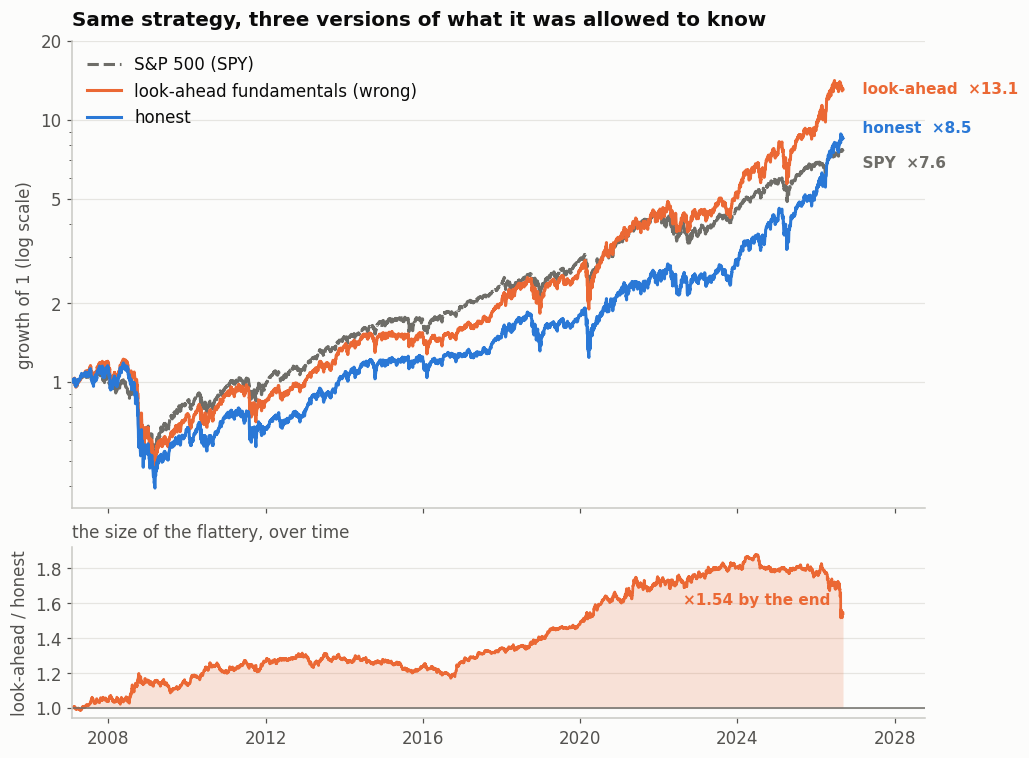

In [3]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1.1], hspace=0.12))

ax.plot(SPY.index, SPY, lw=2, color=C_BENCH, ls="--", label="S&P 500 (SPY)", zorder=2)
ax.plot(EQ["lookahead_fundamentals"].index, EQ["lookahead_fundamentals"], lw=2, color=C_LOOK,
        label="look-ahead fundamentals (wrong)", zorder=3)
ax.plot(EQ["honest"].index, EQ["honest"], lw=2, color=C_HONEST, label="honest", zorder=4)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log scale)")
ax.set_yticks([1, 2, 5, 10, 20]); ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.grid(axis="y", color="#e6e5e1", lw=0.8); ax.set_axisbelow(True)

# direct labels at the right-hand end, so identity does not rest on colour
ends = sorted([(EQ["lookahead_fundamentals"].iloc[-1], C_LOOK, "look-ahead"),
                (EQ["honest"].iloc[-1], C_HONEST, "honest"),
                (SPY.iloc[-1], C_BENCH, "SPY")], key=lambda t: -t[0])
for k, (v, c, name) in enumerate(ends):          # stagger: honest and SPY end within 12 % of each other
    ax.annotate(f"  {name}  \u00d7{v:.1f}", (SPY.index[-1], v), color=c, fontsize=10,
                va="center", fontweight="bold",
                xytext=(6, 0 if k == 0 else (7 if k == 1 else -8)), textcoords="offset points")
ax.set_xlim(SPY.index[0], SPY.index[-1] + pd.Timedelta(days=760))
ax.legend(loc="upper left", ncol=1)
ax.set_title("Same strategy, three versions of what it was allowed to know", loc="left",
             fontsize=13, fontweight="bold", color=INK, pad=10)

ratio = (EQ["lookahead_fundamentals"] / EQ["honest"]).reindex(EQ["honest"].index).ffill()
ax2.fill_between(ratio.index, 1.0, ratio, color=C_LOOK, alpha=0.18, lw=0)
ax2.plot(ratio.index, ratio, lw=1.8, color=C_LOOK)
ax2.axhline(1.0, color=C_BENCH, lw=1.0)
ax2.set_ylabel("look-ahead / honest"); ax2.set_xlabel("")
ax2.grid(axis="y", color="#e6e5e1", lw=0.8); ax2.set_axisbelow(True)
ax2.annotate(f"×{ratio.iloc[-1]:.2f} by the end", (ratio.index[-1], ratio.iloc[-1]),
             xytext=(-8, 6), textcoords="offset points", ha="right", color=C_LOOK, fontsize=10, fontweight="bold")
ax2.set_title("the size of the flattery, over time", loc="left", fontsize=11, color=INK2)
plt.show()

## 2 · Drawdown

The honest run is more volatile than the index and draws down harder. This is the part that a
headline CAGR hides: −67% in March 2009 against the index's −55%.

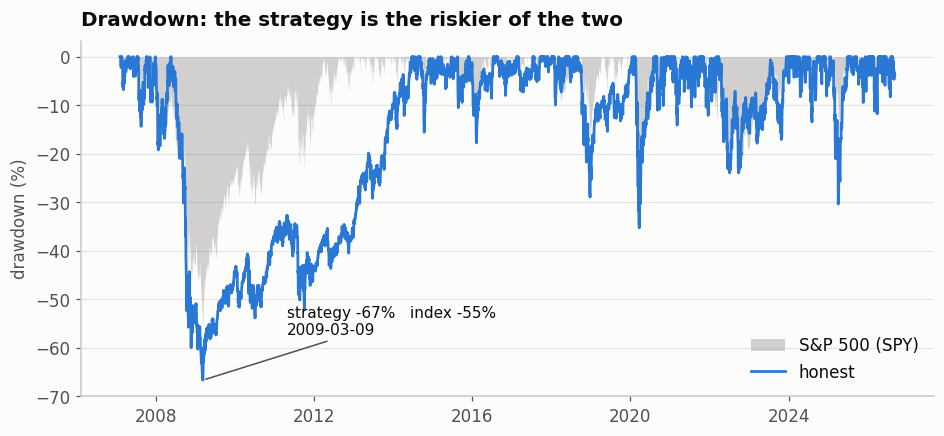

In [4]:
def dd(s): return s / s.cummax() - 1.0

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill_between(SPY.index, 100*dd(SPY), 0, color=C_BENCH, alpha=0.30, lw=0, label="S&P 500 (SPY)")
ax.plot(EQ["honest"].index, 100*dd(EQ["honest"]), lw=1.8, color=C_HONEST, label="honest")
ax.set_ylabel("drawdown (%)"); ax.grid(axis="y", color="#e6e5e1", lw=0.8); ax.set_axisbelow(True)
ax.legend(loc="lower right")
b = R["backtests"]["honest"]
ax.annotate(f"strategy {100*b['strategy']['max_dd']:.0f}%   index {100*b['spy']['max_dd']:.0f}%\n{b['strategy']['max_dd_date']}",
            (pd.Timestamp(b["strategy"]["max_dd_date"]), 100*b["strategy"]["max_dd"]),
            xytext=(55, 30), textcoords="offset points", fontsize=10, color=INK,
            arrowprops=dict(arrowstyle="-", color=INK2, lw=1))
ax.set_title("Drawdown: the strategy is the riskier of the two", loc="left",
             fontsize=13, fontweight="bold", color=INK, pad=10)
plt.show()

## 3 · Year by year

Excess return over the index, per calendar year. Blue where the strategy won, red where it lost.
It wins about half the years — which is what an excess CAGR of half a point looks like up close.

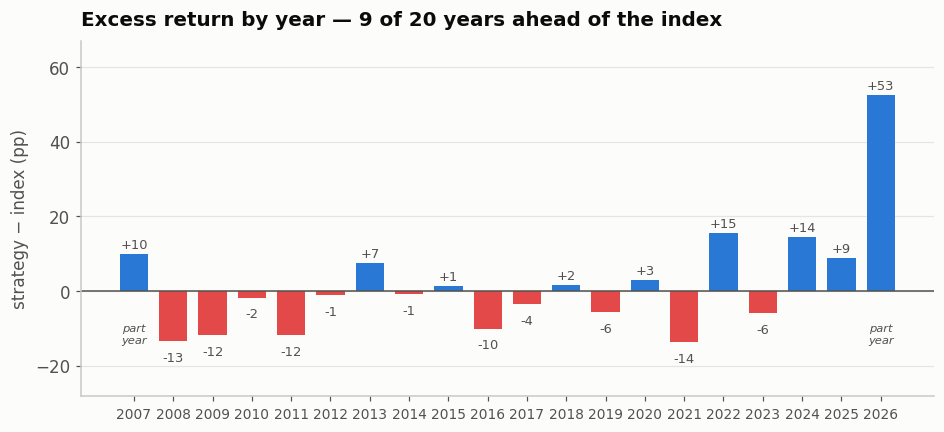

In [5]:
BY = pd.DataFrame(R["backtests"]["honest"]["by_year"]).set_index("year")
ex = 100 * (BY["strategy"] - BY["spy"])

fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.bar(ex.index, ex.values, color=[C_POS if v >= 0 else C_NEG for v in ex.values],
              width=0.72, linewidth=0)
ax.axhline(0, color=INK2, lw=1.0)
ax.set_ylabel("strategy − index (pp)"); ax.set_xticks(ex.index); ax.set_xticklabels(ex.index, rotation=0, fontsize=9)
ax.grid(axis="y", color="#e6e5e1", lw=0.8); ax.set_axisbelow(True)
for x, v in zip(ex.index, ex.values):
    ax.annotate(f"{v:+.0f}", (x, v), xytext=(0, 4 if v >= 0 else -13), textcoords="offset points",
                ha="center", fontsize=8.5, color=INK2)
wins = int((ex > 0).sum())
ax.set_title(f"Excess return by year \u2014 {wins} of {len(ex)} years ahead of the index", loc="left",
             fontsize=13, fontweight="bold", color=INK, pad=10)
# the first and last years are partial: the backtest starts 31 Jan 2007 and ends in September
for x_ in (ex.index[0], ex.index[-1]):
    ax.annotate("part\nyear", (x_, 0), xytext=(0, -34), textcoords="offset points",
                ha="center", fontsize=7.5, color=INK2, style="italic")
ax.margins(y=0.22)
plt.show()

## 4 · The window matters more than the strategy

The first version of this backtest ran from 2023. That window is the last pair of bars. Run it
across the financial crisis instead and the strategy loses to the index by six points a year.

Picking the window is the easiest way to prove anything, which is why the backtest now starts in
2007 and reports each regime separately.

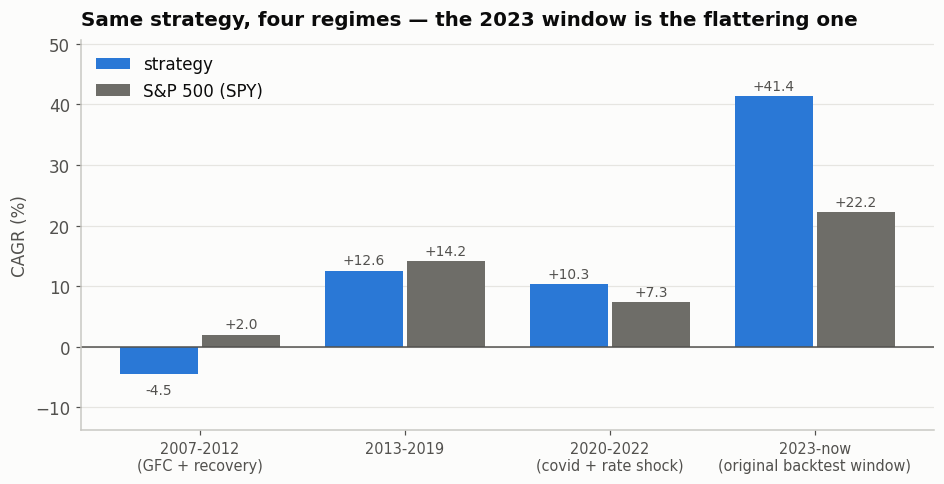

In [6]:
SP = pd.DataFrame(R["backtests"]["honest"]["sub_periods"])
labels = [p.replace(" (", "\n(") for p in SP["period"]]
x = np.arange(len(SP)); w = 0.38

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - w/2 - 0.01, 100*SP["strategy_cagr"], w, color=C_HONEST, linewidth=0, label="strategy")
ax.bar(x + w/2 + 0.01, 100*SP["spy_cagr"], w, color=C_BENCH, linewidth=0, label="S&P 500 (SPY)")
ax.axhline(0, color=INK2, lw=1.0)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("CAGR (%)"); ax.grid(axis="y", color="#e6e5e1", lw=0.8); ax.set_axisbelow(True)
ax.legend(loc="upper left")
for xi, (a, b_) in enumerate(zip(100*SP["strategy_cagr"], 100*SP["spy_cagr"])):
    ax.annotate(f"{a:+.1f}", (xi - w/2 - 0.01, a), xytext=(0, 4 if a >= 0 else -13),
                textcoords="offset points", ha="center", fontsize=9, color=INK2)
    ax.annotate(f"{b_:+.1f}", (xi + w/2 + 0.01, b_), xytext=(0, 4 if b_ >= 0 else -13),
                textcoords="offset points", ha="center", fontsize=9, color=INK2)
ax.set_title("Same strategy, four regimes — the 2023 window is the flattering one", loc="left",
             fontsize=13, fontweight="bold", color=INK, pad=10)
ax.margins(y=0.20)
plt.show()

## 5 · What the free data can actually see

The remaining survivorship bias, quantified. `members` is how many names were in the index that
year; `with prices` is how many the free data source still serves. The gap is companies that were
acquired, delisted or renamed — they were in the index, they are not in the backtest, and their
absence is not neutral.

It is worst in the early years, which is exactly where the strategy does worst.

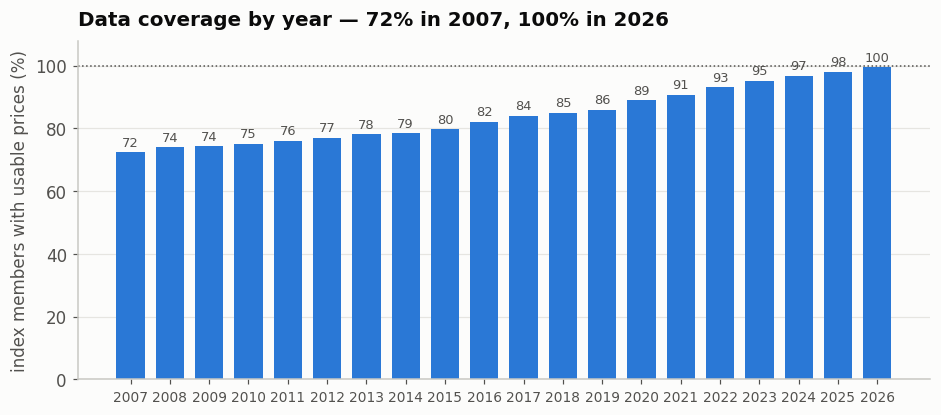

2007: 497 members, 360 with prices, 140 passed the screen
2026: 503 members, 501 with prices, 131 passed the screen


In [7]:
CV = pd.DataFrame(R["backtests"]["honest"]["coverage_by_year"]).set_index("year")
cov = 100 * CV["with_prices"] / CV["members"]

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.bar(CV.index, cov.values, color=C_HONEST, width=0.72, linewidth=0)
ax.axhline(100, color=INK2, lw=1.0, ls=":")
ax.set_ylim(0, 108); ax.set_ylabel("index members with usable prices (%)")
ax.set_xticks(CV.index); ax.set_xticklabels(CV.index, fontsize=9)
ax.grid(axis="y", color="#e6e5e1", lw=0.8); ax.set_axisbelow(True)
for x_, v, m, wp in zip(CV.index, cov.values, CV["members"], CV["with_prices"]):
    ax.annotate(f"{v:.0f}", (x_, v), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=8.5, color=INK2)
ax.set_title(f"Data coverage by year — {cov.iloc[0]:.0f}% in {CV.index[0]}, {cov.iloc[-1]:.0f}% in {CV.index[-1]}",
             loc="left", fontsize=13, fontweight="bold", color=INK, pad=10)
plt.show()

print(f"{CV.index[0]}: {CV['members'].iloc[0]} members, {CV['with_prices'].iloc[0]} with prices, "
      f"{CV['eligible'].iloc[0]} passed the screen")
print(f"{CV.index[-1]}: {CV['members'].iloc[-1]} members, {CV['with_prices'].iloc[-1]} with prices, "
      f"{CV['eligible'].iloc[-1]} passed the screen")

## 6 · The current signal

What the live screen produced at the last rebalance. The live signal does use fundamentals — they
are known at trade time — which is why the backtest above does not.

In [8]:
S = R["signal"]
sig = pd.read_csv(RES / f"signal_{S['asof']}.csv")
print(f"as of {S['asof']} · {S['eligible']} names passed the screen · "
      f"fundamentals {'used' if S['fundamentals_used'] else 'unavailable, price-only'}")
print(f"\ntarget ({len(S['target'])}): " + "  ".join(S["target"]))
print("\nsector mix: " + ",  ".join(f"{k} {v}" for k, v in sorted(S["sector_mix"].items(), key=lambda kv: -kv[1])))
cols = [c for c in ("ticker", "rank", "status", "momentum", "roe", "eps", "market_cap") if c in sig.columns]
display(sig[cols].head(20))

as of 2026-08-31 · 56 names passed the screen · fundamentals used

target (20): CAT  GOOGL  TPR  APH  FSLR  HPE  FTNT  CSCO  STT  HWM  NTAP  ADI  MS  DAL  IBKR  LUV  TXN  GS  JCI  PCAR

sector mix: Information Technology 8,  Industrials 6,  Financials 4,  Communication Services 1,  Consumer Discretionary 1


,ticker,rank,status
0,HPE,1.0,BUY
1,FTNT,2.0,BUY
2,CAT,3.0,HOLD
3,CSCO,4.0,BUY
4,GOOGL,5.0,HOLD
5,STT,6.0,BUY
6,HWM,7.0,BUY
7,NTAP,8.0,BUY
8,TPR,9.0,HOLD
9,ADI,10.0,BUY


## What this says

- The strategy does not beat the index. Over 19.6 years it is **+0.64 points of CAGR** ahead with
  **more volatility and a deeper drawdown** — a worse Sharpe than simply holding SPY.
- The version that *did* look good was reading fundamentals it could not have known. That was worth
  **+2.5 points a year**, about four fifths of the apparent edge.
- The original 2023 start date was the other half of the illusion. Across the crisis the same rules
  lose to the index by six points a year.
- Residual survivorship remains: in 2007 the free data serves 72% of the index members. Everything
  above should be read with that in mind, and it is the main reason not to trust the early years.

None of which makes the strategy good. It makes the number believable, which was the point.